# Documentation of the baseline correction for duecker_ET_model

This code explains how and why the baseline correction method was developed for the duecker_ET_model.



In [1]:
# Author: Katharina Duecker <katharina_duecker@brown.edu>

## 1. Import libraries and set up environment

We'll start by importing the necessary `hnn_core` modules and other libraries required for this tutorial.

In [2]:
import os.path as op
import matplotlib.pyplot as plt
import hnn_core

from hnn_core import duecker_ET_model, simulate_dipole, MPIBackend

from hnn_core.optimization import Optimizer

import numpy as np
from scipy.optimize import curve_fit

hnn_core_root = op.join(op.dirname(hnn_core.__file__))

# The number of cores may need modifying depending on your current machine.
n_procs = 10


## 2. Run a long simulation without external drives

Different resting membrane potentials in the compartments of our pyramidal neurons cause a non-zero dipole,   
which we need to correct for such that our dipolar signal is close to 0 in absence of any inputs.  
To develop a baseline correction method, we first run a long simulation without any external drives.

In [3]:
tstop = 1000  # ms
net_no_drives = duecker_ET_model()     # load network

# Run a single trial without any inputs. Set the baseline correction to bsl_cor='none' to avoid any automatic correction.
# Important: the baseline correction has to be set to 'none' (as a string) instead of None (the Python object), 
# as None would default to the standard baseline correction method for the jones_2009_model.
# We will also record the membrane voltages in all compartments using record_vsec='all'.

with MPIBackend(n_procs=n_procs, mpi_cmd='mpiexec'):
    dpl_net_no_drives = simulate_dipole(net_no_drives, tstop=tstop, n_trials=1, bsl_cor='none', record_vsec='all')[0]

/Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/dipole.py:84: UserWarning: No external drives or biases loaded
  warnings.warn("No external drives or biases loaded", UserWarning)


MPI will run 1 trial(s) sequentially by distributing network neurons over 10 processes.
numprocs=10
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Load

## 3. Explore the dipole and membrane voltages

As the figure shows, the dipole signal (left) is not centered around 0, but shows a drift over time.  
This is mainly driven by layer 5. The reason for this non-zero dipole lies in the different resting membrane potentials in the different compartments.  
To illustrate this, we plot the membrane voltages in all compartments of one L2/3 pyramidal neuron (middle) and one L5 pyramidal neuron (right).  
As you can see, in the right-most plot, the apical dendrite has a higher resting membrane potential than the soma, leading to a non-zero dipole moment.

Text(0.5, 1.0, 'L5 pyramidal neuron')

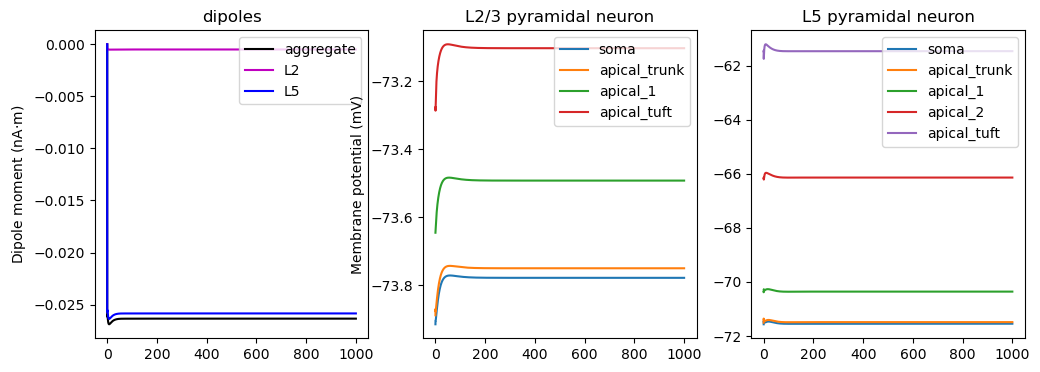

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(dpl_net_no_drives.times, dpl_net_no_drives.data['agg'], linewidth=1.5, color='k', label='aggregate')
ax[0].plot(dpl_net_no_drives.times, dpl_net_no_drives.data['L2'], linewidth=1.5, color='m', label='L2')
ax[0].plot(dpl_net_no_drives.times, dpl_net_no_drives.data['L5'], linewidth=1.5, color='b', label='L5')
ax[0].set_title('dipoles')
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Dipole moment (nA$\cdot$m)')
yticks = []
yticklabels = []
for s, section in enumerate(['soma', 'apical_trunk', 'apical_1', 'apical_tuft']):
    v_s = net_no_drives.cell_response.vsec[0][35][section]
    ax[1].plot(dpl_net_no_drives.times, np.array(v_s), label=section, linewidth=1.5)

ax[1].legend(loc='upper right')
ax[1].set_title('L2/3 pyramidal neuron')
ax[1].set_ylabel('Membrane potential (mV)')

yticks = []
yticklabels = []
prev_v = -80
for s, section in enumerate(['soma', 'apical_trunk', 'apical_1', 'apical_2', 'apical_tuft']):
    v_s = net_no_drives.cell_response.vsec[0][170][section]
    ax[2].plot(dpl_net_no_drives.times, np.array(v_s), label=section, linewidth=1.5)
    yticklabels.append(np.round(np.min(np.array(v_s)),2))
    yticklabels.append(np.round(np.max(np.array(v_s)),2))

ax[2].legend(loc='upper right')
ax[2].set_title('L5 pyramidal neuron')

## 4. Fit an exponential function to the drift

The previous figure shows an approximately exponential decay in the dipole signal over time.  
We will correct for this drift by fitting an exponential function to the dipole signal and subtracting this fit from the original signal.  
The dipoles, time vector, and estimated parameters of the exponential function are stored in hnn_core/param/bsl_dipole_dueckerET.json.  
and will be loaded automatically when using the 'duecker' baseline correction.   
The code below shows applies the baseline correction method as implemented in hnn_core.dipole._baseline_renormalize_dueckerET.  

In [5]:
def exp_decay(t, A, C, b):
    
    return ((C-A) * np.exp(-b*(t))) + A

def _exp_decay_wrapper_l2(t, b):
        return exp_decay(t, A_L2, C_L2, b)

def _exp_decay_wrapper_l5(t, b):
        return exp_decay(t, A_L5, C_L5, b)

# store dipoles in dictionary
bsl_dipole_ca = {'times': dpl_net_no_drives.times.tolist(),
                 'L2': dpl_net_no_drives.data['L2'].tolist(),
                 'L5': dpl_net_no_drives.data['L5'].tolist()}

# get parameters 
A_L2 = bsl_dipole_ca['L2'][-1]
A_L5 = bsl_dipole_ca['L5'][-1]

C_L2 = bsl_dipole_ca['L2'][1]
C_L5 = bsl_dipole_ca['L5'][1]

# fit exponential decay to dipole data, from second sample to avoid fitting an offset
popt_l2, pcov = curve_fit(_exp_decay_wrapper_l2, bsl_dipole_ca['times'][1:], bsl_dipole_ca['L2'][1:], p0=(0.01), bounds=(0, np.inf))             
popt_l5, pcov = curve_fit(_exp_decay_wrapper_l2, bsl_dipole_ca['times'][1:], bsl_dipole_ca['L5'][1:], p0=(0.01), bounds=(0, np.inf))

exp_fit_l2 = _exp_decay_wrapper_l2(np.array(bsl_dipole_ca['times']), *popt_l2)
exp_fit_l5 = _exp_decay_wrapper_l5(np.array(bsl_dipole_ca['times']), *popt_l5)

bsl_dipole_ca['popt_l2'] = list(popt_l2)
bsl_dipole_ca['popt_l5'] = list(popt_l5)

## 5. Explore the results

The figure below compares the original dipole signals with the fitted exponential decay functions and corrected dipoles.
As you can see, the baseline-corrected dipoles (right) are now roughly centered around 0.

Text(0.5, 1.0, 'Baseline corrected dipoles')

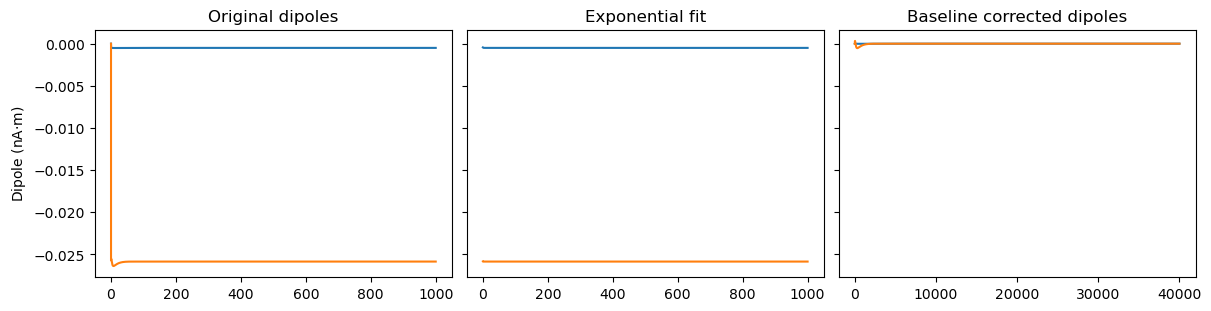

In [6]:
fig, ax = plt.subplots(1,3, figsize=(12,3), constrained_layout=True, sharey=True)
ax[0].plot(dpl_net_no_drives.times, dpl_net_no_drives.data['L2'])
ax[0].plot(dpl_net_no_drives.times, dpl_net_no_drives.data['L5'])
ax[0].set_title('Original dipoles')
ax[0].set_ylabel('Dipole (nA$\cdot$m)')
ax[1].plot(dpl_net_no_drives.times[1:], exp_fit_l2[1:])
ax[1].plot(dpl_net_no_drives.times[1:], exp_fit_l5[1:])
ax[1].set_title('Exponential fit')
dpl_net_no_drives.data['L2'][1:] -= exp_fit_l2[1:]
dpl_net_no_drives.data['L5'][1:] -= exp_fit_l5[1:]
ax[2].plot(dpl_net_no_drives.data['L2'])
ax[2].plot(dpl_net_no_drives.data['L5'])
ax[2].set_title('Baseline corrected dipoles')

## 6. Applying the baseline correction in an HNN simulation

The code below shows how the baseline correction is applied automatically when simulating the dipole with bsl_cor='duecker',  
and shows the unscaled dipole, and dipole scaled by a factor of 1000 as used in the ERP simulations.


/Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/dipole.py:84: UserWarning: No external drives or biases loaded
  warnings.warn("No external drives or biases loaded", UserWarning)


MPI will run 1 trial(s) sequentially by distributing network neurons over 10 processes.
numprocs=10
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /Users/katharinaduecker/Documents/projects_brown/hnn-tuning/local_hnn/hnn_core/mod/arm64/.libs/libnrnmech.so
Load

Text(0.5, 1.0, 'Baseline corrected and scaled dipole')

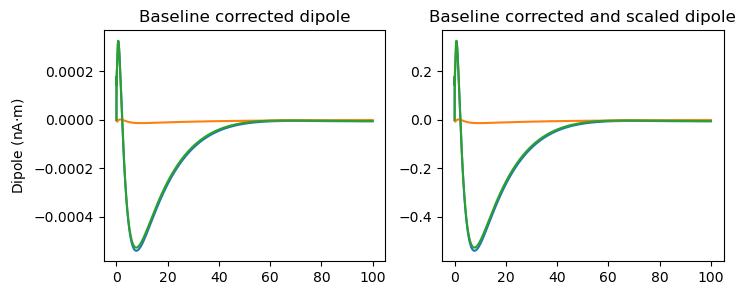

In [7]:
net_test = duecker_ET_model()
# For demonstration purposes, we set a shorter tstop here.
with MPIBackend(n_procs=n_procs, mpi_cmd='mpiexec'):
    dpl_test = simulate_dipole(net_test, tstop=100, n_trials=1, bsl_cor='duecker')[0]

fig, ax = plt.subplots(1,2,figsize=(8,3))
ax[0].plot(dpl_test.times,dpl_test.data['agg'])
ax[0].plot(dpl_test.times,dpl_test.data['L2'])
ax[0].plot(dpl_test.times,dpl_test.data['L5'])
ax[0].set_title('Baseline corrected dipole')
ax[0].set_ylabel('Dipole (nA$\cdot$m)')
dpl_test.scale(1000)

ax[1].plot(dpl_test.times,dpl_test.data['agg'])
ax[1].plot(dpl_test.times,dpl_test.data['L2'])
ax[1].plot(dpl_test.times,dpl_test.data['L5'])
ax[1].set_title('Baseline corrected and scaled dipole')